In [1]:
from pathlib import Path

print(Path.cwd())

/home/dyretna/Dokument/Code/GitHub/AI-fractals/notebooks


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
PROJECT_ROOT.exists()

True

# AI-Enhanced shoreline extraction

### Methodology for Generating Fractal Images
The first step in AI-enhanced fractal shoreline extraction involves generating
fractal images. This can be achieved using various mathematical methods, such as
iterated function systems (IFS), complex dynamics, or escape-time algorithms. For
illustration, we will focus on generating the Mandelbrot and Julia sets.

#### Generating the Mandelbrot Set: 
The Mandelbrot set is defined by iterating the
function zn+1=zn2+cz_{n+1} = z_n^2 + czn+1=zn2+c, where ccc is a complex
number and z0=0z_0 = 0z0=0. The set includes all points ccc for which the
sequence does not escape to infinity.

## mandelbrot set

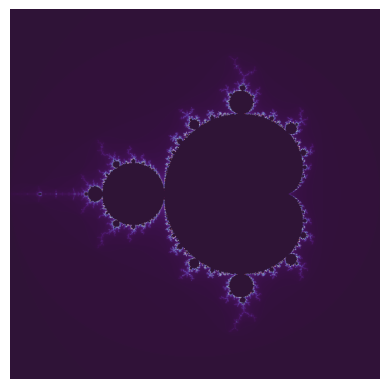

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_mandelbrot(xmin, xmax, ymin, ymax, width, height, max_iter):
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros(C.shape, dtype=complex)

    img = np.zeros(C.shape, dtype=int)
    for i in range(max_iter):
        mask = np.abs(Z) < 2
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        img += mask

    return img


# Generate and plot the mandelbrot set
mandelbrot_img = generate_mandelbrot(-2.0, 1.0, -1.5, 1.5, 800, 600, 256)
plt.imshow(mandelbrot_img, extent=[-2.0, 1.0, -1.5, 1.5], cmap='twilight_shifted')
plt.axis('off')
plt.savefig('mandelbrot.png', bbox_inches='tight', pad_inches=0)
plt.show()

## Automatic exploration via tiling

Split the current view into a **5x5 grid** (25 tiles) -> score each tile -> pick a random passing candidate -> zoom in -> repeat.

**Selection strategy:** random among candidates above threshold at all depths.  
Intermediate depths (2-5) tend to produce richer shorelines than very deep zooms (narrow filaments).


In [4]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from ai_fractals.generators import MandelbrotGenerator
from ai_fractals.analysis import FractalQualityEvaluator

load_dotenv()
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))


class FractalSearcher:
    def __init__(
        self,
        save_img: bool = True,
        save_min_depth: int = 2,
        save_max_depth: int = 7,
        width: int = 1200,
        height: int = 1200,
        max_iter: int = 900,
        tile_resolution: int = 200,
        quality_threshold: float = 0.3,
        n_tiles: int = 5,
        output_dir: Path = PROJECT_ROOT / "dataset" / "fractals" / "mandelbrot",
    ):
        self.save_img = save_img
        self.save_min_depth = save_min_depth
        self.save_max_depth = save_max_depth
        self.max_iter = max_iter
        self.n_tiles = n_tiles
        self.output_dir = Path(output_dir).resolve()
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.tile_gen = MandelbrotGenerator(width=tile_resolution, height=tile_resolution, max_iter=max_iter)
        self.hires_gen = MandelbrotGenerator(width=width, height=height, max_iter=max_iter)
        self.evaluator = FractalQualityEvaluator(quality_threshold=quality_threshold)

        self.bounds = (-2.0, 1.0, -1.5, 1.5)
        self.depth = 0

        print(f"Output dir: {self.output_dir}")
        print(f"Dir exists: {self.output_dir.exists()}")

    def reset(self):
        self.bounds = (-2.0, 1.0, -1.5, 1.5)
        self.depth = 0
        print(f"Reset: {self.bounds}")

    def _tile_and_score(self, xmin, xmax, ymin, ymax):
        xs = np.linspace(xmin, xmax, self.n_tiles + 1)
        ys = np.linspace(ymin, ymax, self.n_tiles + 1)
        tiles = []
        for row in range(self.n_tiles):
            for col in range(self.n_tiles):
                bounds = (xs[col], xs[col + 1], ys[row], ys[row + 1])
                raw = self.tile_gen.generate_raw(*bounds)
                img = self.tile_gen.generate(*bounds)
                score, accept, metrics = self.evaluator.evaluate(raw)
                tiles.append({
                    'bounds': bounds, 'score': score, 'accept': accept,
                    'img': img, 'pos': (row, col),
                })
        return tiles

    def _show_tiles(self, tiles):
        n = self.n_tiles
        fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))
        axes = np.array(axes).reshape(n, n)
        candidates = []
        for t in tiles:
            row, col = t['pos']
            ax = axes[row, col]
            ax.imshow(t['img'])
            color = '#44ff88' if t['accept'] else '#ff4444'
            ax.set_title(f"{t['score']:.2f}", color=color, fontsize=11, fontweight='bold')
            ax.axis('off')
            if t['accept']:
                candidates.append(t)
        plt.suptitle(
            f"{len(candidates)}/{len(tiles)} above threshold ({self.evaluator.quality_threshold})",
            y=1.01,
        )
        plt.tight_layout()
        plt.show()
        return candidates

    def step(self):
        self.evaluator.quality_threshold = 0.12 if self.depth == 0 else 0.3

        tiles = self._tile_and_score(*self.bounds)
        candidates = self._show_tiles(tiles)

        pool = candidates if candidates else sorted(tiles, key=lambda t: t['score'], reverse=True)[:3]
        chosen = random.choice(pool)

        self.bounds = chosen['bounds']
        self.depth += 1

        xmin, xmax, ymin, ymax = chosen['bounds']
        hires = self.hires_gen.generate(xmin, xmax, ymin, ymax)
        self.plot(hires, chosen, xmin, xmax, ymin, ymax)

        if self.save_img and chosen['accept'] and self.save_min_depth <= self.depth <= self.save_max_depth:
            self.save(hires, xmin, ymin)
        else:
            reason = []
            if not chosen['accept']:
                reason.append("below threshold (fallback)")
            if not (self.save_min_depth <= self.depth <= self.save_max_depth):
                reason.append(f"depth {self.depth} outside save range [{self.save_min_depth}-{self.save_max_depth}]")
            print(f"Not saved: {', '.join(reason) if reason else 'save_img=False'} -- run again to go deeper.")

    def plot(self, hires, chosen, xmin, xmax, ymin, ymax):
        fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
        ax.imshow(hires, interpolation='lanczos')
        ax.axis('off')
        ax.set_title(
            f"Depth {self.depth}  score {chosen['score']:.2f}\n"
            f"x=[{xmin:.6f}, {xmax:.6f}]  y=[{ymin:.6f}, {ymax:.6f}]",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()

    def save(self, hires, xmin, ymin):
        fname = self.output_dir / f"d{self.depth:02d}_{xmin:.5f}_{ymin:.5f}.png"
        ok = cv2.imwrite(str(fname), cv2.cvtColor(hires, cv2.COLOR_RGB2BGR))
        if ok:
            print(f"Saved: {fname}")
        else:
            print(f"ERROR: cv2.imwrite failed for {fname}")


print("FractalSearcher ready.")


FractalSearcher ready.


In [5]:
searcher = FractalSearcher()


Output dir: /home/dyretna/Dokument/Code/Local/01_personal_projects/AI_fractals/dataset/fractals/mandelbrot
Dir exists: True


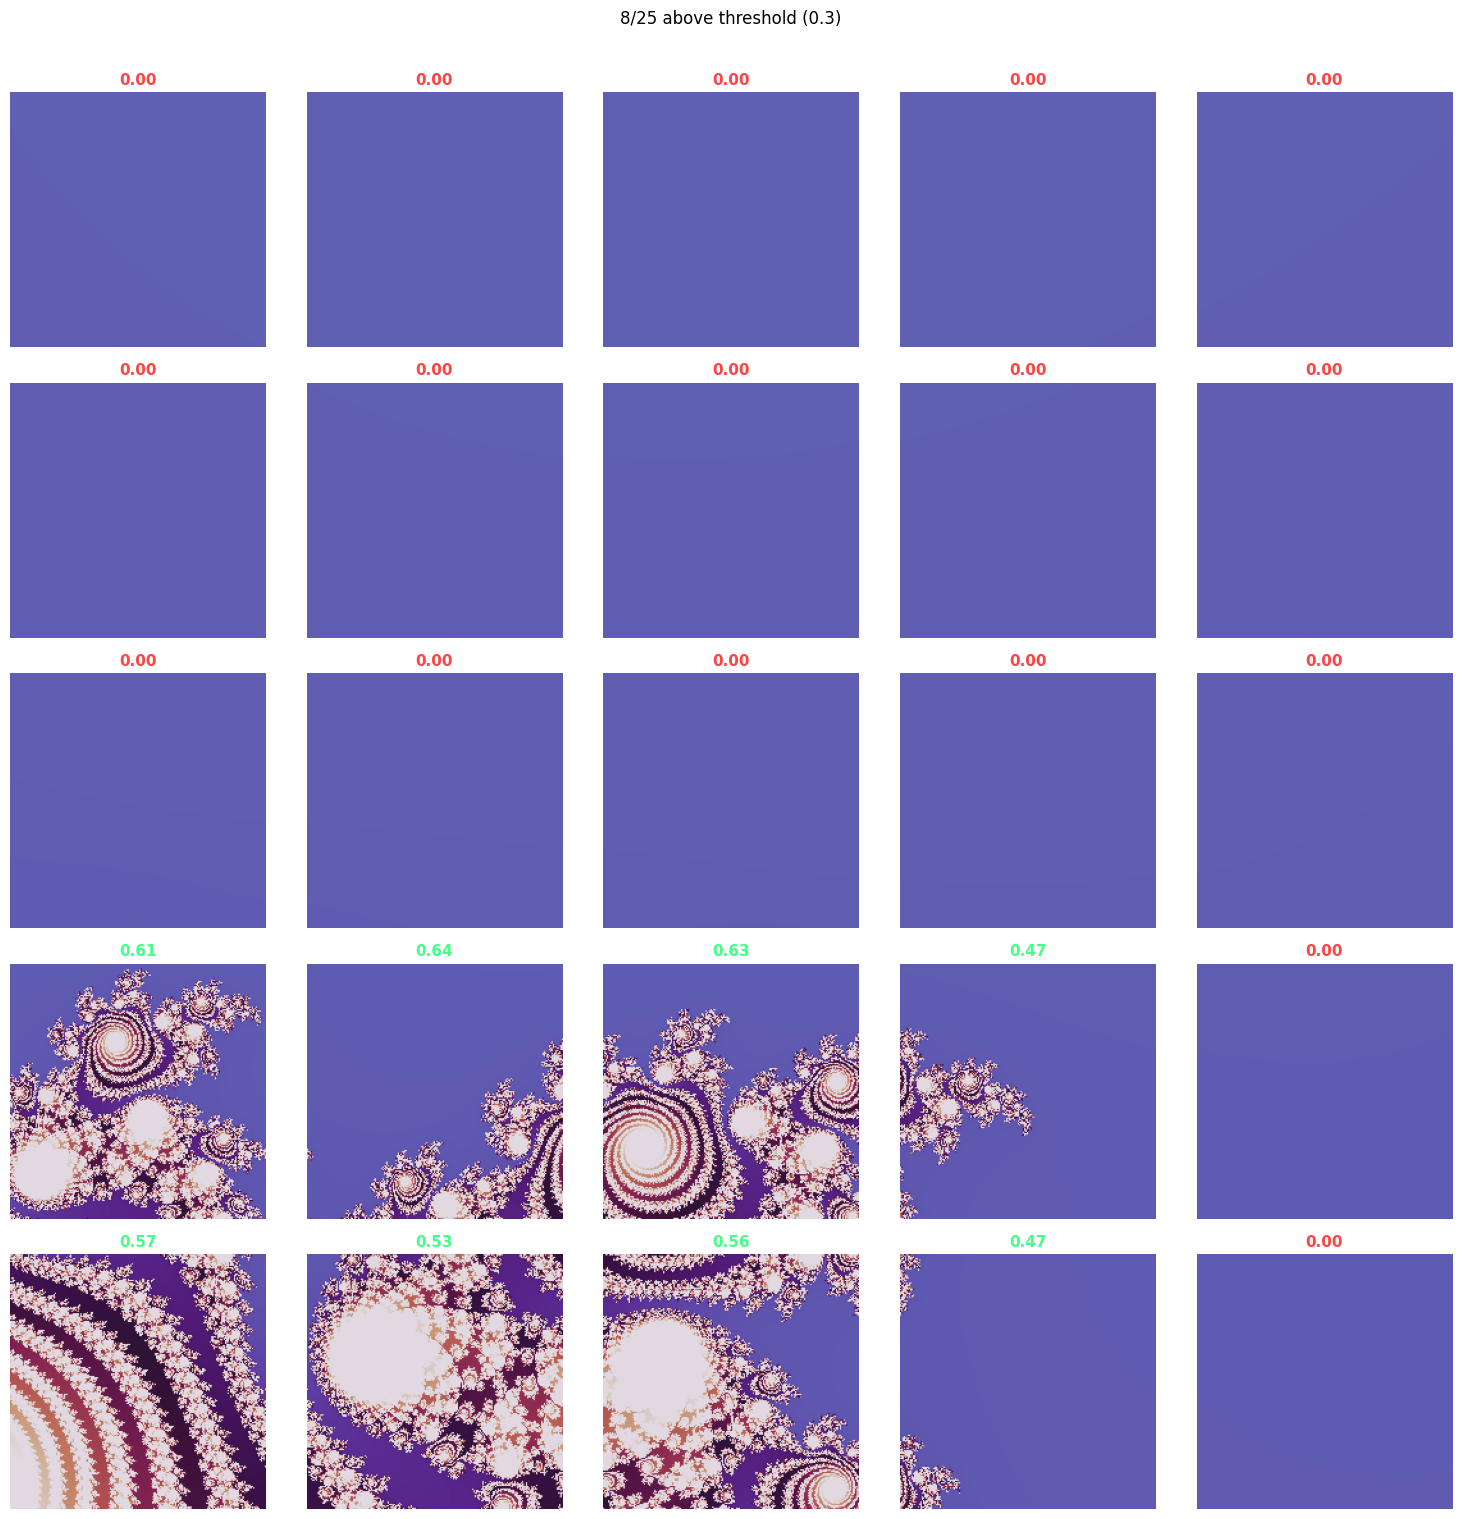

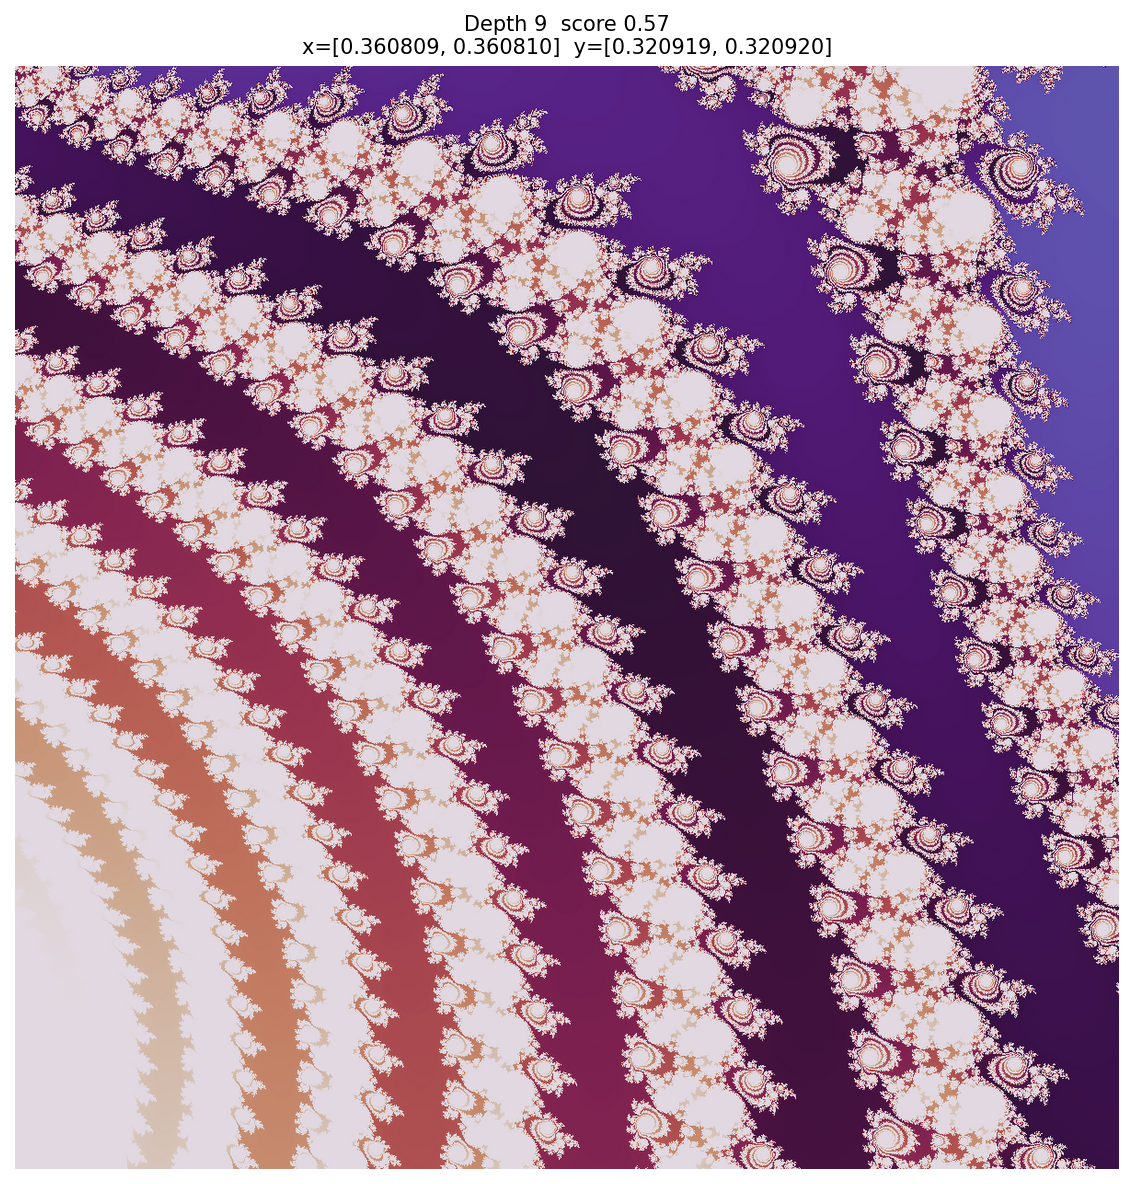

Not saved: depth 9 outside save range [2-7] -- run again to go deeper.


In [14]:
# Run repeatedly to zoom deeper. Reset with searcher.reset()
searcher.step()
